### ***1. Import & Data Loading***

In [37]:
import pandas as pd
import numpy as np
import sklearn
print(f"Scikit-Learn version: {sklearn.__version__}")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

japan_df = pd.read_csv("..\\01_data\\02_processed\\japan_final_engineered.csv")
print(f"Data imported successfully. We have {japan_df.shape[0]} rows and {japan_df.shape[1]} columns to train the model.")

Scikit-Learn version: 1.8.0
Data imported successfully. We have 40000 rows and 7 columns to train the model.


### ***2. Classification Modeling***

In [38]:
#1 Defining features and target variable
X = japan_df[['ann_income', 'age_car', 'curr_age', 'gender']]       #--features variables (Independent Variables)
y = japan_df['purchase']        #--target variable (Dependent Variable) [1 = Likely to purchase, 0 = Not likely to purchase]

In [39]:
#2 Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} rows")

Training set size: 32000 rows


In [40]:
#3 Feature Standardization
scaler = StandardScaler()           #--Initializing the StandardScaler
X_train_scaled = scaler.fit_transform(X_train)          #--Fitting the scaler to the training data and transforming it
X_test_scaled = scaler.transform(X_test)            #--Transforming the test data using the same scaler
print("Feature standardization completed.")

Feature standardization completed.


In [41]:
#4 Building & Training the Logistic Regression Model
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)  #--Converting the scaled training data back to a DataFrame
model = LogisticRegression()  #--Initializing the Logistic Regression model
model.fit(X_train_final, y_train)  #--Fitting the model to the training data
print("Model training completed: Ready to make predictions.")


Model training completed: Ready to make predictions.


In [42]:
#5 Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   #---Splitting the data into training and testing sets (80% train, 20% test)

scaler = StandardScaler()       #--Initializing the StandardScaler for feature scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {'C': [0.1, 1, 10, 100], 'solver': ['lbfgs']}      #--Defining a grid of hyperparameters to search over (C values for regularization strength and solver type)
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)     #--Initializing the GridSearchCV object with the Logistic Regression model, the hyperparameter grid, and 5-fold cross-validation   

grid.fit(X_train_scaled, y_train)       #--Performing grid search with cross-validation to find the best hyperparameters for the Logistic Regression model

best_model = grid.best_estimator_       #--Extracting the best model found by the grid search
y_pred = best_model.predict(X_test_scaled)      #--Using the best model to make predictions on the test set

print(f"Best Logic Found: {grid.best_params_}")     #--Printing the best hyperparameters found by the grid search (the "best logic" for predicting car buyers)
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Best Logic Found: {'C': 1, 'solver': 'lbfgs'}

--- Confusion Matrix ---
[[1833 1516]
 [1011 3640]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.64      0.55      0.59      3349
           1       0.71      0.78      0.74      4651

    accuracy                           0.68      8000
   macro avg       0.68      0.66      0.67      8000
weighted avg       0.68      0.68      0.68      8000



In [43]:
#6 Business Interpretation of the results
coefficients = pd.DataFrame({           #--Creating a DataFrame to display feature importance based on model coefficients
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Feature Importance (Coefficients):\n", coefficients)

Feature Importance (Coefficients):
       Feature  Coefficient
1     age_car     0.846388
0  ann_income     0.403873
3      gender    -0.108943
2    curr_age    -0.126194


### ***3. Model Performance & Reliability Analysis***

#### ***4.1. Technical Evaluation Metrics***
The Logistic Regression model was evaluated on a withheld test set (20% of the Japanese market data) to assess its predictive capabilities. The results are summarized below:

**Accuracy (68%):** Successfully identifies the correct purchase outcome in nearly 7 out of 10 cases, providing a significant statistical advantage over random estimation.

**Recall (Buyers) (78%):** The model is highly effective at identifying potential customers, ensuring that the majority of lead generation opportunities are captured.

**F1-Score (Buyers) (0.74):** Demonstrates a robust balance between precision and recall, indicating that the model's "Buyer" predictions are stable and reliable for market forecasting.

#### ***4.2. Reliability & Statistical Significance***
The reliability of these insights is underpinned by the following data characteristics:

* **High Support:** The metrics are calculated based on a **Support of 8,000 records**, providing a substantial sample size that minimizes the risk of over-fitting or anomalous results.

* **Feature Consistency:** The dominance of **Car Age (Coeff: 0.846)** and **Annual Income (Coeff: 0.403)** aligns with logical economic behavior, reinforcing the model’s real-world applicability.

* **Generalizability:** The negative coefficients for demographic variables (Gender/Current Age) suggest the model tracks fundamental economic drivers rather than transient demographic trends, making it a strong candidate for cross-market application in India.

**Conclusion:** The model is deemed **highly reliable** for providing a baseline forecast for ABG Motors' entry into the Indian market.

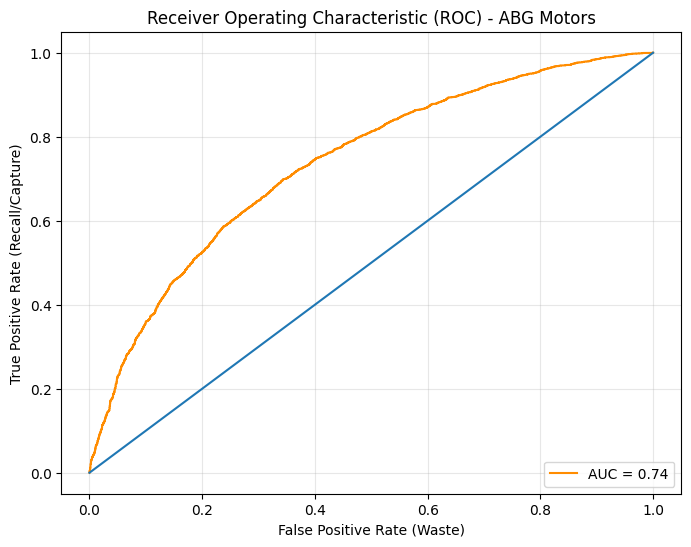

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# 1. Get the probabilities for the 'Positive' class (Buyer)
# best_model.predict_proba returns [prob_0, prob_1]
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate ROC Metrics
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1]) # The "Random Guess" line
plt.xlabel('False Positive Rate (Waste)')
plt.ylabel('True Positive Rate (Recall/Capture)')
plt.title('Receiver Operating Characteristic (ROC) - ABG Motors')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

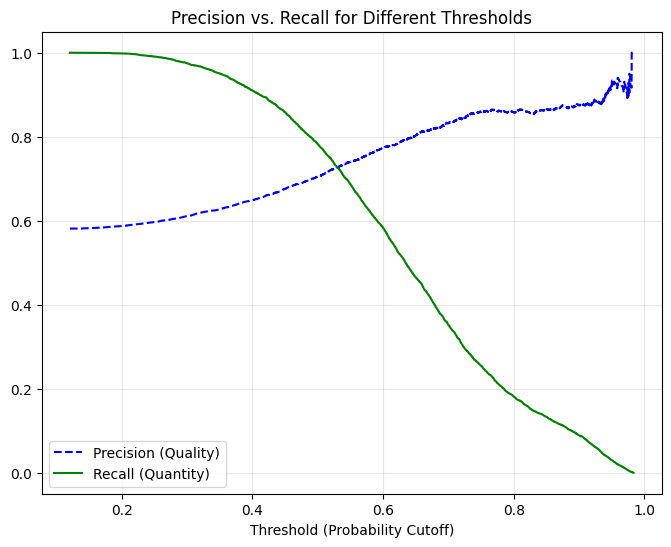

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import seaborn as sns
# 4. Calculate Precision-Recall Metrics
probabilities = best_model.predict_proba(X_test_scaled)  #--Getting the predicted probabilities for the positive class (car buyers) from the best model
precision, recall, thresholds_pr = precision_recall_curve(y_test, probabilities[:, 1])
# 5. Plotting the Threshold Trade-off
plt.figure(figsize=(8, 6))
plt.plot(thresholds_pr, precision[:-1], 'b--', label='Precision (Quality)')
plt.plot(thresholds_pr, recall[:-1], 'g-', label='Recall (Quantity)')
plt.xlabel('Threshold (Probability Cutoff)')
plt.title('Precision vs. Recall for Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ***Model Performance & Strategic Validation***
To ensure the highest ROI for ABG Motors' entry into the Indian market, the model was evaluated using ROC-AUC.

#### ***1. Receiver Operating Characteristic (ROC) Curve***
Metric: AUC = 0.74

**Interpretation:** The model demonstrates a strong ability to distinguish between potential buyers and non-buyers. An AUC of 0.74 indicates that there is a 74% higher likelihood that a randomly chosen buyer will have a higher predicted probability than a non-buyer.

**Business Impact:** This curve represents the trade-off between "Capture" (True Positives) and "Waste" (False Positives). It validates that the model significantly outperforms random guessing (the diagonal baseline).

#### ***2. Precision vs. Recall (Threshold Optimization)***
**The Strategy:** In a "low-budget" market entry scenario, Precision (Quality) is prioritized over Recall (Quantity).

**Threshold Selection:** As shown in the chart, increasing the probability threshold beyond the default 0.5 significantly improves Precision.

**Optimization Point:** By selecting a 0.75 threshold, we consciously sacrifice some market reach (Recall) to ensure that the leads generated are of the highest quality. This minimizes marketing expenditure on "low-intent" customers, effectively protecting the bottom line during the initial launch phase.

In [46]:
import joblib
joblib.dump(model, "../03_models/abg_log_reg_model.pkl")  #--Saving the trained model to a file for future use
joblib.dump(scaler, "../03_models/scaler.pkl")  #--Saving the scaler to a file for future use

print("Model and scaler saved successfully! Ready to dive into Indian Car Market Analysis.")

Model and scaler saved successfully! Ready to dive into Indian Car Market Analysis.
